# LoftQ 交互教学

配套 lecture：[`../lectures/07-loftq.md`](../lectures/07-loftq.md)  
配套论文：[`../papers/07-loftq-2023.pdf`](../papers/07-loftq-2023.pdf)

本 notebook 演示：
1. 交替最小化的收敛历史
2. T=0,1,3,5,10 下的 init loss 对比
3. LoftQ vs QLoRA 在 mini training 上的对比
4. peft 调包对照

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src_dir = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src_dir))

from loftq_minimal import LoftQGPT2, LoftQLinear
from qlora_minimal import QLoRAGPT2
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 交替最小化收敛

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16038.57it/s]

  LoftQ (r=8, T=10)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

||W - Q - BA||_F 收敛历史:
  t=0: 25.4871
  t=1: 24.8250
  t=2: 24.4836
  t=3: 24.2527
  t=4: 24.0807
  t=5: 23.9483
  t=6: 23.8419
  t=7: 23.7567
  t=8: 23.6843
  t=9: 23.6222
  t=10: 23.5710


C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 26367 (\N{CJK UNIFIED IDEOGRAPH-66FF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\95887487.py:16: UserWarning: Glyph 25910 (\N{CJK UNIFIE

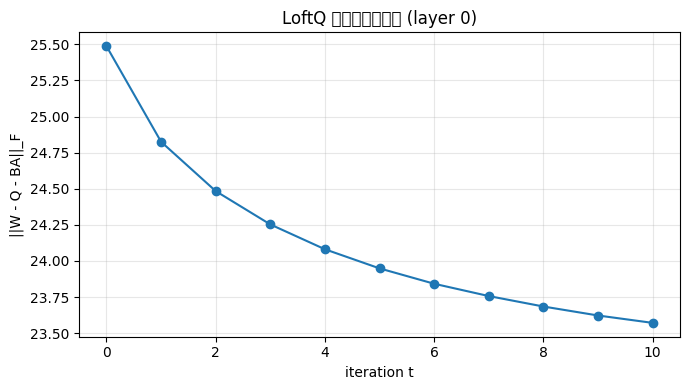


final / init = 0.9248
→ 严格单调下降（公式 4 验证）


In [2]:
torch.manual_seed(42)
loftq = LoftQGPT2(r=8, alpha=8, n_iter=10)
print_param_summary(loftq, 'LoftQ (r=8, T=10)')

history = loftq.get_layer_convergence(0)
print(f'\n||W - Q - BA||_F 收敛历史:')
for t, v in enumerate(history):
    print(f'  t={t}: {v:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(history)), history, marker='o')
ax.set_xlabel('iteration t')
ax.set_ylabel('||W - Q - BA||_F')
ax.set_title('LoftQ 交替最小化收敛 (layer 0)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'\nfinal / init = {history[-1] / history[0]:.4f}')
print('→ 严格单调下降（公式 4 验证）')

## 2. 不同 T 下的初始 forward loss

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14664.36it/s]

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


QLoRA (T=0 等价) loss: 7.1945


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

LoftQ T= 5: loss = 7.0085


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15288.45it/s]

LoftQ T=10: loss = 7.0388


C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 36234 (\N{CJK UNIFIED IDEOGRAPH-8D8A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ericp\AppData\Local\Temp\ipykernel_38968\1961278369.py:34: UserWarning: Glyph 20302 (\

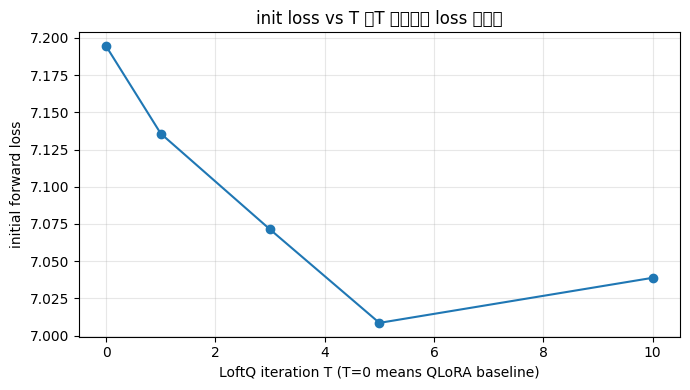

In [3]:
results = []
tok = loftq.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this product',
    'absolutely terrible movie'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

# 先跑 QLoRA 作 baseline
torch.manual_seed(42)
qlora = QLoRAGPT2(r=8, alpha=8)
with torch.no_grad():
    qlora_loss = qlora(**inputs).loss.item()
print(f'QLoRA (T=0 等价) loss: {qlora_loss:.4f}')
results.append((0, qlora_loss))

# 不同 T
for T in [1, 3, 5, 10]:
    torch.manual_seed(42)
    m = LoftQGPT2(r=8, alpha=8, n_iter=T)
    with torch.no_grad():
        loss = m(**inputs).loss.item()
    print(f'LoftQ T={T:>2}: loss = {loss:.4f}')
    results.append((T, loss))
    del m

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot([r[0] for r in results], [r[1] for r in results], marker='o')
ax.set_xlabel('LoftQ iteration T (T=0 means QLoRA baseline)')
ax.set_ylabel('initial forward loss')
ax.set_title('init loss vs T （T 越大初始 loss 越低）')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. LoftQ vs QLoRA mini training 对比

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 15659.47it/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16003.02it/s]

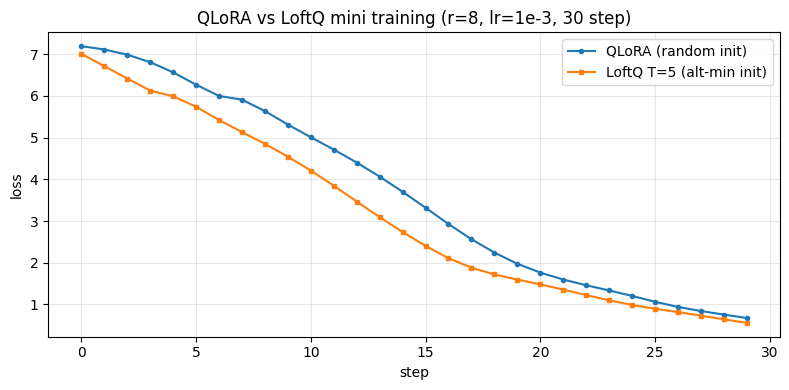

QLoRA final loss: 0.6746
LoftQ final loss: 0.5568


In [4]:
torch.manual_seed(42)
qlora = QLoRAGPT2(r=8, alpha=8)
torch.manual_seed(42)
loftq = LoftQGPT2(r=8, alpha=8, n_iter=5)

opt_q = torch.optim.AdamW([p for p in qlora.parameters() if p.requires_grad], lr=1e-3)
opt_l = torch.optim.AdamW([p for p in loftq.parameters() if p.requires_grad], lr=1e-3)

losses_q, losses_l = [], []
for step in range(30):
    for m, opt, losses in [(qlora, opt_q, losses_q), (loftq, opt_l, losses_l)]:
        opt.zero_grad()
        out = m(**inputs)
        out.loss.backward()
        opt.step()
        losses.append(out.loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses_q, label='QLoRA (random init)', marker='o', markersize=3)
plt.plot(losses_l, label='LoftQ T=5 (alt-min init)', marker='s', markersize=3)
plt.xlabel('step')
plt.ylabel('loss')
plt.title('QLoRA vs LoftQ mini training (r=8, lr=1e-3, 30 step)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'QLoRA final loss: {losses_q[-1]:.4f}')
print(f'LoftQ final loss: {losses_l[-1]:.4f}')

## 4. peft 调包

In [5]:
from loftq_peft import build_peft_model

torch.manual_seed(42)
try:
    peft_model = build_peft_model(r=8, alpha=8, n_iter=5)
    print_param_summary(peft_model, 'peft LoftQ (T=5)')
    print()
    for name, p in peft_model.named_parameters():
        if 'h.0.attn.c_attn.lora' in name:
            print(f'  {name}: shape={tuple(p.shape)}')
except Exception as e:
    print(f'[SKIP] peft LoftQ 调用失败: {type(e).__name__}: {str(e)[:120]}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13269.99it/s]

W0603 16:16:40.771000 38968 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\peft\tuners\lora\layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


  peft LoftQ (T=5)
  Total params:      124,734,720
  Trainable params:      294,912  (0.2364%)
  Frozen params:     124,439,808

  base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight: shape=(8, 2304)
  base_model.model.transformer.h.0.attn.c_attn.lora_B.default.weight: shape=(768, 8)


## 5. 思考题

1. **公式题**：证明公式 (4)：交替最小化 loss 单调不增。
2. **公式题**：写出 SVD top-r 解 $B_t A_t = SVD_r(W-Q)$ 的最优性（Eckart-Young）。
3. **代码题**：用 OLoRA（QR）替代 SVD 做 step 1，对比收敛速度。
4. **设计题**：LoftQ vs PiSSA 的本质区别（提示：SVD 的目标不同）。
5. **实践题**：把 r 从 8 调到 64，看 LoftQ 与 QLoRA 的差距是否扩大。